# Qwen3.8 Multi-Token Prediction with OpenVINO™

This experimental notebook demonstrates built-in Multi-Token Prediction (MTP) speculative decoding for [Qwen3.8-27B](https://huggingface.co/Qwen/Qwen3.8-27B) with OpenVINO GenAI `VLMPipeline`.

MTP uses the draft head stored in the Qwen checkpoint. The main model validates several draft tokens in one inference iteration, which can improve token-generation throughput without using a separate small language model.

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Select inference device](#Select-inference-device)
- [Get a model with an MTP head](#Get-a-model-with-an-MTP-head)
- [Prepare an image](#Prepare-an-image)
- [Run the baseline](#Run-the-baseline)
- [Run MTP speculative decoding](#Run-MTP-speculative-decoding)
- [Compare results](#Compare-results)
    - [Optional lookahead sweep](#Optional-lookahead-sweep)
- [Extended validation](#Extended-validation)
    - [Cross-check with the OpenVINO GenAI benchmark sample](#Cross-check-with-the-OpenVINO-GenAI-benchmark-sample)

⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO and is using a custom branch of optimum-intel. It may be fully supported and validated in the future.

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/qwen3.8-mtp/qwen3.8-mtp.ipynb" />



## Prerequisites
[back to top ⬆️](#Table-of-contents:)

Install required packages and setup helper functions.


In [ ]:
%pip install -q -U --pre openvino openvino-tokenizers openvino-genai --extra-index-url https://storage.openvinotoolkit.org/simple/wheels/nightly
%pip install -q -U "optimum-intel @ git+https://github.com/openvino-agent/optimum-intel.git@qwen35_mtp" "transformers==5.2.0" "nncf==3.3.0" Pillow ipywidgets huggingface-hub --extra-index-url https://download.pytorch.org/whl/cpu


In [1]:
from pathlib import Path
import subprocess
import sys

import requests

import openvino as ov
import openvino_genai as ov_genai

if not Path("notebook_utils.py").exists():
    response = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(response.text)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("qwen3.8-mtp.ipynb")


## Select inference device
[back to top ⬆️](#Table-of-contents:)

NPU does not support this experimental MTP path and is excluded from the list. The outputs saved in this notebook come from a GPU run.


In [2]:
import ipywidgets as widgets
from IPython.display import display

from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU", "AUTO"])
display(device)


Dropdown(description='Device:', options=('CPU', 'GPU'), value='CPU')

## Get a model with an MTP head
[back to top ⬆️](#Table-of-contents:)

OpenVINO GenAI uses `openvino_mtp_model.xml` from the model directory as the draft model. Both preconverted models on Hugging Face contain the required MTP model:

- [OpenVINO/Qwen3.8-27B-int4-ov](https://huggingface.co/OpenVINO/Qwen3.8-27B-int4-ov)
- [OpenVINO/Qwen3.8-27B-int8-ov](https://huggingface.co/OpenVINO/Qwen3.8-27B-int8-ov)

The INT4 model is downloaded by default. Select local export only if you want to convert [Qwen/Qwen3.8-27B](https://huggingface.co/Qwen/Qwen3.8-27B) with `optimum-cli` instead. Local export downloads the original weights and may require significant time and memory.

The local INT4 export passes `--group-size-fallback adjust`: some projection nodes in Qwen3.8 have a channel count that the default INT4 group size does not divide, and NNCF adjusts the group size for those nodes instead of failing.


In [3]:
PRECONVERTED_MODELS = {
    "hub_int4": "OpenVINO/Qwen3.8-27B-int4-ov",
    "hub_int8": "OpenVINO/Qwen3.8-27B-int8-ov",
}
EXPORT_MODEL_ID = "Qwen/Qwen3.8-27B"

MODEL_DIRS = {
    source: Path(model_id.split("/")[-1]) for source, model_id in PRECONVERTED_MODELS.items()
}
MODEL_DIRS["export"] = Path("Qwen3.8-27B-int4-ov-local")

model_source = widgets.RadioButtons(
    options=[
        (f"Download {PRECONVERTED_MODELS['hub_int4']} from Hugging Face", "hub_int4"),
        (f"Download {PRECONVERTED_MODELS['hub_int8']} from Hugging Face", "hub_int8"),
        (f"Export {EXPORT_MODEL_ID} locally with optimum-cli", "export"),
    ],
    value="hub_int4",
    layout=widgets.Layout(width="max-content"),
)
display(model_source)


RadioButtons(layout=Layout(width='max-content'), options=(('Download OpenVINO/Qwen3.8-27B-int4-ov from Hugging…

In [4]:
import shutil

MODEL_DIR = MODEL_DIRS[model_source.value]
mtp_xml = MODEL_DIR / "openvino_mtp_model.xml"

if mtp_xml.exists():
    print(f"Using existing MTP-enabled model: {MODEL_DIR.resolve()}")
elif model_source.value in PRECONVERTED_MODELS:
    import huggingface_hub as hf_hub

    hub_model_id = PRECONVERTED_MODELS[model_source.value]
    print(f"Downloading {hub_model_id}...")
    hf_hub.snapshot_download(hub_model_id, local_dir=MODEL_DIR)
else:
    optimum_cli = shutil.which("optimum-cli")
    if optimum_cli is None:
        raise RuntimeError("optimum-cli was not found. Run the prerequisite cell and restart the kernel.")

    command = [
        optimum_cli,
        "export",
        "openvino",
        "--model",
        EXPORT_MODEL_ID,
        "--task",
        "image-text-to-text",
        "--weight-format",
        "int4",
        "--group-size-fallback",
        "adjust",
        str(MODEL_DIR),
    ]
    print("Running:", " ".join(command))
    subprocess.run(command, check=True)

print(f"Model directory: {MODEL_DIR.resolve()}")


Using existing MTP-enabled model: C:\Users\amokrov\source\openvino-workspace\scratch\qwen3.8-mtp-test\Qwen3.8-27B-int4-ov
Model directory: C:\Users\amokrov\source\openvino-workspace\scratch\qwen3.8-mtp-test\Qwen3.8-27B-int4-ov


In [5]:
if not MODEL_DIR.exists():
    raise FileNotFoundError(f"Model directory does not exist: {MODEL_DIR.resolve()}")

required_mtp_files = [MODEL_DIR / "openvino_mtp_model.xml", MODEL_DIR / "openvino_mtp_model.bin"]
missing_mtp_files = [path.name for path in required_mtp_files if not path.exists()]
if missing_mtp_files:
    raise RuntimeError(
        f"The model is not MTP-enabled; missing {missing_mtp_files}. "
        "Download one of the preconverted OpenVINO models or export the original Qwen checkpoint locally."
    )

xml_files = sorted(path.name for path in MODEL_DIR.glob("*.xml"))
print("OpenVINO submodels:")
for name in xml_files:
    print(f"  {name}")


OpenVINO submodels:
  openvino_detokenizer.xml
  openvino_language_model.xml
  openvino_mtp_model.xml
  openvino_text_embeddings_model.xml
  openvino_tokenizer.xml
  openvino_vision_embeddings_merger_model.xml
  openvino_vision_embeddings_model.xml
  openvino_vision_embeddings_pos_model.xml


## Prepare an image
[back to top ⬆️](#Table-of-contents:)

Download a sample image and convert it to an OpenVINO tensor. Replace `IMAGE_PATH` or `PROMPT` to test another request.


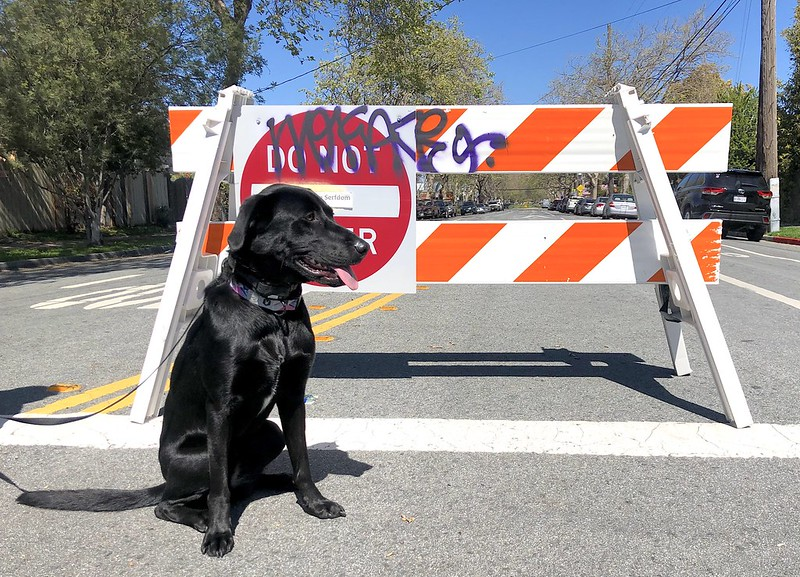

Prompt: Describe this image in detail.


In [6]:
from urllib.request import urlretrieve

import numpy as np
from PIL import Image
from IPython.display import display

IMAGE_URL = "https://storage.openvinotoolkit.org/repositories/openvino_notebooks/data/data/image/coco.jpg"
IMAGE_PATH = Path("coco.jpg")
PROMPT = "Describe this image in detail."

if not IMAGE_PATH.exists():
    urlretrieve(IMAGE_URL, IMAGE_PATH)

pil_image = Image.open(IMAGE_PATH).convert("RGB")
display(pil_image)
image_tensor = ov.Tensor(np.asarray(pil_image))
print(f"Prompt: {PROMPT}")


In [7]:
import gc
import time

MAX_NEW_TOKENS = 64
NUM_ASSISTANT_TOKENS = 1


def make_scheduler_config():
    scheduler_config = ov_genai.SchedulerConfig()
    # Hybrid-attention speculative verification currently requires prefix caching to be disabled.
    scheduler_config.enable_prefix_caching = False
    # Same as benchmark_vlm.py: keep the prompt and every validation window in a single forward pass.
    scheduler_config.max_num_batched_tokens = sys.maxsize
    return scheduler_config


def make_generation_config(num_assistant_tokens=0, max_new_tokens=MAX_NEW_TOKENS):
    config = ov_genai.GenerationConfig()
    config.max_new_tokens = max_new_tokens
    config.do_sample = False
    config.num_return_sequences = 1
    config.assistant_confidence_threshold = 0.0
    config.num_assistant_tokens = num_assistant_tokens
    return config


def run_generation(pipe, config, warmup=True):
    if warmup:
        warmup_config = make_generation_config(config.num_assistant_tokens, max_new_tokens=4)
        pipe.generate(PROMPT, images=[image_tensor], generation_config=warmup_config)

    started = time.perf_counter()
    result = pipe.generate(PROMPT, images=[image_tensor], generation_config=config)
    elapsed = time.perf_counter() - started
    text = result.texts[0]
    token_count = result.perf_metrics.get_num_generated_tokens()
    throughput = result.perf_metrics.get_throughput().mean
    return result, text, elapsed, token_count, throughput


def print_result(label, text, elapsed, token_count, throughput):
    print(f"{label} output:\n{text}\n")
    print(f"Elapsed:    {elapsed:.2f} s")
    print(f"Tokens:     {token_count}")
    print(f"Throughput: {throughput:.2f} tokens/s")


## Run the baseline
[back to top ⬆️](#Table-of-contents:)

First run Qwen3.8 with the Continuous Batching backend but without a draft model. The pipeline is released before MTP is loaded to avoid keeping two copies of the 27B main model in memory.


In [8]:
print("Loading baseline VLMPipeline...")
load_started = time.perf_counter()
baseline_pipe = ov_genai.VLMPipeline(
    str(MODEL_DIR),
    device.value,
    scheduler_config=make_scheduler_config(),
)
print(f"Loaded in {time.perf_counter() - load_started:.2f} s")

baseline_config = make_generation_config()
baseline_result, baseline_text, baseline_elapsed, baseline_tokens, baseline_throughput = run_generation(
    baseline_pipe, baseline_config
)
print_result("Baseline", baseline_text, baseline_elapsed, baseline_tokens, baseline_throughput)

del baseline_result, baseline_pipe
gc.collect()
print("Baseline pipeline released.")


Loading baseline VLMPipeline...
Loaded in 45.71 s
Baseline output:
The user wants a detailed description of this image. Let me carefully observe all elements before writing.

Starting with the main subject: a black dog, looks like a Labrador Retriever or similar breed, sitting on asphalt. It's facing to the right (profile view), mouth open with tongue hanging out, panting

Elapsed:    10.42 s
Tokens:     64
Throughput: 6.54 tokens/s
Baseline pipeline released.


## Run MTP speculative decoding
[back to top ⬆️](#Table-of-contents:)

`draft_model()` picks up `openvino_mtp_model.xml` from the model directory, and the pipeline feeds the main model's hidden states to that head to obtain the proposed tokens.

The implementation supports greedy decoding, a single return sequence, and a fixed `num_assistant_tokens`. This run proposes one token; the sweep below shows which value is fastest on the current machine.


In [9]:
print("Loading MTP VLMPipeline...")
load_started = time.perf_counter()
mtp_draft = ov_genai.draft_model(str(MODEL_DIR), device.value)
mtp_pipe = ov_genai.VLMPipeline(
    str(MODEL_DIR),
    device.value,
    draft_model=mtp_draft,
    scheduler_config=make_scheduler_config(),
)
print(f"Loaded in {time.perf_counter() - load_started:.2f} s")

mtp_config = make_generation_config(NUM_ASSISTANT_TOKENS)
mtp_result, mtp_text, mtp_elapsed, mtp_tokens, mtp_throughput = run_generation(mtp_pipe, mtp_config)
print_result("MTP", mtp_text, mtp_elapsed, mtp_tokens, mtp_throughput)


Loading MTP VLMPipeline...
Loaded in 47.86 s
MTP output:
The user wants a detailed description of this image. Let me carefully observe all elements before writing.

Starting with the main subject: a black dog, looks like a Labrador or similar breed, sitting on asphalt. It's facing right (profile view), mouth open with pink tongue hanging out, suggesting panting/heat.

Elapsed:    6.77 s
Tokens:     64
Throughput: 10.58 tokens/s


## Compare results
[back to top ⬆️](#Table-of-contents:)

Compare the text, both speedups, and the acceptance metrics. Throughput counts decoding only, while the wall-clock time also includes the vision encoder and the prompt prefill, which MTP does not change, so the wall-clock speedup is the smaller of the two.


In [10]:
outputs_match = baseline_text == mtp_text
wall_clock_speedup = baseline_elapsed / mtp_elapsed
throughput_speedup = mtp_throughput / baseline_throughput

print(f"Greedy outputs match: {outputs_match}")
print(f"Wall-clock speedup:   {wall_clock_speedup:.2f}x")
print(f"Throughput speedup:   {throughput_speedup:.2f}x")

sd_metrics = getattr(mtp_result, "extended_perf_metrics", None)
if sd_metrics:
    print(f"Draft candidates:     {sd_metrics.get_num_draft_tokens()}")
    print(f"Accepted candidates:  {sd_metrics.get_num_accepted_tokens()}")
    print(f"Acceptance rate:      {sd_metrics.get_draft_acceptance_rate():.2%}")
else:
    print("Speculative metrics are unavailable. Verify that the latest OpenVINO GenAI nightly is installed.")

if not outputs_match:
    print("WARNING: MTP output differs from the greedy baseline; preserve both outputs when reporting the issue.")


Greedy outputs match: False
Wall-clock speedup:   1.54x
Throughput speedup:   1.62x
Draft candidates:     32
Accepted candidates:  30
Acceptance rate:      93.75%


### Optional lookahead sweep
[back to top ⬆️](#Table-of-contents:)

Acceptance and speedup depend on the prompt and on how many tokens are proposed. The sweep reuses the loaded MTP pipeline to compare one, two, and three assistant tokens on the same request.


In [11]:
run_sweep = widgets.Checkbox(value=False, description="Run lookahead sweep", indent=False)
display(run_sweep)


Checkbox(value=False, description='Run lookahead sweep', indent=False)

In [12]:
if run_sweep.value:
    print("assistant tokens | elapsed (s) | throughput (token/s) | acceptance")
    print("-----------------|-------------|----------------------|-----------")
    for assistant_tokens in (1, 2, 3):
        config = make_generation_config(assistant_tokens)
        result, _, elapsed, _, throughput = run_generation(mtp_pipe, config, warmup=False)
        metrics = getattr(result, "extended_perf_metrics", None)
        acceptance = metrics.get_draft_acceptance_rate() if metrics else float("nan")
        print(f"{assistant_tokens:^16} | {elapsed:11.2f} | {throughput:20.2f} | {acceptance:9.2%}")
else:
    print("Sweep is disabled.")


assistant tokens | elapsed (s) | throughput (token/s) | acceptance
-----------------|-------------|----------------------|-----------
       1         |        6.80 |                10.47 |    93.75%
       2         |        6.09 |                11.85 |    72.00%
       3         |        5.63 |                13.49 |    68.33%


In [13]:
del mtp_result, mtp_pipe, mtp_draft
gc.collect()
print("MTP pipeline released.")


MTP pipeline released.


## Extended validation
[back to top ⬆️](#Table-of-contents:)

The comparison above uses a single prompt. This section runs a grid: every selected `num_assistant_tokens` value against a list of prompts that alternates image requests with text-only ones, so even a short selection covers both the vision encoder and plain decoding. For each value it reports throughput, speedup over the greedy baseline, mean acceptance rate, and how many answers are identical to the baseline, and it checks that unsupported generation configurations are rejected. Acceptance falls as the lookahead grows, so the fastest value is the peak of the speedup column, not the largest lookahead. The baseline pass runs first and is released before the MTP pipeline is created, so only one copy of the 27B model is in memory at a time.

Greedy MTP output is usually identical to the baseline, but it is not guaranteed to be bit-exact: the main model verifies several tokens in one forward pass, and a token whose logit nearly ties with another one can flip, after which the texts differ to the end. Every mismatch is therefore printed with its divergence point and both continuations. Continuations that read well and have a similar token count are this effect; a truncated, repetitive, or off-topic continuation is worth reporting on the PR. A mismatch that repeats at several lookahead values is not suspicious by itself, because the main model evaluates a multi-token query at every one of them.


In [14]:
run_validation = widgets.Checkbox(value=False, description="Run extended validation", indent=False)
run_benchmark = widgets.Checkbox(value=False, description="Run benchmark_vlm.py", indent=False)
# One checkbox per lookahead value, so that selecting several of them takes plain clicks.
assistant_token_boxes = {
    value: widgets.Checkbox(value=value <= 3, description=str(value), indent=False, layout=widgets.Layout(width="55px"))
    for value in range(1, 7)
}
prompt_count = widgets.IntSlider(value=3, min=1, max=9, description="Prompts:")

display(
    run_validation,
    widgets.HBox([widgets.Label("Assist:"), *assistant_token_boxes.values()]),
    prompt_count,
    run_benchmark,
)
print("Validation generates prompts x (1 baseline + one pass per selected assist value) answers of 128 tokens")
print("and loads the model twice. The full grid of 9 prompts and 6 assist values takes tens of minutes on CPU.")


Checkbox(value=False, description='Run extended validation', indent=False)

IntSlider(value=3, description='Prompts:', max=9, min=1)

Checkbox(value=False, description='Run benchmark_vlm.py', indent=False)

Validation generates prompts x (1 baseline + one pass per selected assist value) answers of 128 tokens
and loads the model twice. The full grid of 9 prompts and 6 assist values takes tens of minutes on CPU.


In [15]:
# The kinds alternate, so that a short selection still covers both the vision encoder and text-only decoding.
VALIDATION_PROMPTS = [
    ("image", "Describe this image in detail."),
    ("text", "Explain in three sentences how speculative decoding works."),
    ("image", "List the objects in the picture and say where each of them is located."),
    ("text", "Name three differences between INT4 and INT8 weight compression."),
    ("image", "What is the setting of this picture and what time of day is it?"),
    ("text", "Write a Python function that reverses the words in a sentence."),
    ("image", "Count the living beings in the picture and describe each of them."),
    ("text", "Summarize what multi-token prediction is in two sentences."),
    ("image", "Read any text visible in the picture. If there is none, say so."),
]
VALIDATION_MAX_NEW_TOKENS = 128

UNSUPPORTED_CONFIGS = {
    "sampling": {"do_sample": True, "temperature": 0.8},
    "beam-like multiple sequences": {"num_return_sequences": 2},
    "dynamic acceptance threshold": {"assistant_confidence_threshold": 0.5},
}


def warmup(pipe, num_assistant_tokens):
    config = make_generation_config(num_assistant_tokens, max_new_tokens=4)
    pipe.generate(PROMPT, images=[image_tensor], generation_config=config)


def run_prompts(pipe, prompts, num_assistant_tokens):
    records = []
    for kind, prompt in prompts:
        config = make_generation_config(num_assistant_tokens, max_new_tokens=VALIDATION_MAX_NEW_TOKENS)
        images = [image_tensor] if kind == "image" else []
        result = pipe.generate(prompt, images=images, generation_config=config)
        extended_metrics = getattr(result, "extended_perf_metrics", None)
        records.append(
            {
                "kind": kind,
                "prompt": prompt,
                "text": result.texts[0],
                "tokens": result.perf_metrics.get_num_generated_tokens(),
                "throughput": result.perf_metrics.get_throughput().mean,
                "acceptance": extended_metrics.get_draft_acceptance_rate() if extended_metrics else float("nan"),
            }
        )
    return records


def average(values):
    return sum(values) / len(values)


def common_prefix_length(left, right):
    limit = min(len(left), len(right))
    index = 0
    while index < limit and left[index] == right[index]:
        index += 1
    return index


def report_comparison(label, baseline_output, mtp_output):
    baseline_value, baseline_token_count = baseline_output
    mtp_value, mtp_token_count = mtp_output
    if baseline_value == mtp_value:
        print(f"  [match] {label}, {baseline_token_count} tokens")
        return

    prefix = common_prefix_length(baseline_value, mtp_value)
    share = prefix / max(len(baseline_value), 1)
    print(f"  [diverges] {label}")
    print(f"    identical prefix: {prefix} of {len(baseline_value)} characters ({share:.0%})")
    print(f"    tokens: baseline {baseline_token_count}, MTP {mtp_token_count}")
    print(f"    baseline continues: {baseline_value[prefix:prefix + 90]!r}")
    print(f"    MTP continues:      {mtp_value[prefix:prefix + 90]!r}")


def check_unsupported_configs(pipe, num_assistant_tokens):
    for name, overrides in UNSUPPORTED_CONFIGS.items():
        config = make_generation_config(num_assistant_tokens, max_new_tokens=8)
        for key, value in overrides.items():
            setattr(config, key, value)
        try:
            pipe.generate(PROMPT, images=[image_tensor], generation_config=config)
            print(f"  {name}: accepted, no error reported")
        except Exception as error:
            print(f"  {name}: rejected as expected ({str(error).strip().splitlines()[0][:110]})")


if run_validation.value:
    prompts = VALIDATION_PROMPTS[: prompt_count.value]
    assistant_tokens_grid = [value for value, box in assistant_token_boxes.items() if box.value]
    if not assistant_tokens_grid:
        raise ValueError("Select at least one assist value above.")

    print(f"Baseline pass over {len(prompts)} prompts, grid {assistant_tokens_grid}...")
    validation_pipe = ov_genai.VLMPipeline(
        str(MODEL_DIR),
        device.value,
        scheduler_config=make_scheduler_config(),
    )
    warmup(validation_pipe, 0)
    baseline_records = run_prompts(validation_pipe, prompts, 0)
    del validation_pipe
    gc.collect()
    baseline_throughput = average([record["throughput"] for record in baseline_records])
    print(f"Baseline throughput: {baseline_throughput:.2f} tokens/s")

    print("\nLoading MTP pipeline...")
    validation_draft = ov_genai.draft_model(str(MODEL_DIR), device.value)
    validation_pipe = ov_genai.VLMPipeline(
        str(MODEL_DIR),
        device.value,
        draft_model=validation_draft,
        scheduler_config=make_scheduler_config(),
    )
    warmup(validation_pipe, assistant_tokens_grid[0])

    print("Checking unsupported configurations...")
    check_unsupported_configs(validation_pipe, assistant_tokens_grid[0])

    table_rows = []
    for assistant_tokens in assistant_tokens_grid:
        print(f"\nMTP pass with num_assistant_tokens={assistant_tokens}...")
        mtp_records = run_prompts(validation_pipe, prompts, assistant_tokens)
        mtp_throughput = average([record["throughput"] for record in mtp_records])
        acceptance = average([record["acceptance"] for record in mtp_records])
        matches = sum(mtp["text"] == base["text"] for mtp, base in zip(mtp_records, baseline_records))
        table_rows.append((assistant_tokens, mtp_throughput, mtp_throughput / baseline_throughput, acceptance, matches))

        for mtp, base in zip(mtp_records, baseline_records):
            if mtp["text"] != base["text"]:
                report_comparison(
                    f"({base['kind']}) {base['prompt']}",
                    (base["text"], base["tokens"]),
                    (mtp["text"], mtp["tokens"]),
                )

    del validation_pipe, validation_draft
    gc.collect()

    print(f"\nBaseline throughput: {baseline_throughput:.2f} tokens/s over {len(prompts)} prompts")
    print("assist | MTP tokens/s | speedup | acceptance | output match")
    print("-------|--------------|---------|------------|-------------")
    for assistant_tokens, mtp_throughput, speedup, acceptance, matches in table_rows:
        print(
            f"{assistant_tokens:^6} | {mtp_throughput:12.3f} | {speedup:6.3f}x | "
            f"{acceptance:10.2%} | {matches:>6}/{len(prompts)}"
        )
else:
    print("Extended validation is disabled.")


Baseline pass over 3 prompts, grid [1, 2, 3, 4]...
Baseline throughput: 6.63 tokens/s

Loading MTP pipeline...
Checking unsupported configurations...
  sampling: rejected as expected (Check 'config.is_greedy_decoding()' failed at C:\Jenkins\workspace\private-ci\ie\build-windows-vs2022@2\b\repo)
  beam-like multiple sequences: rejected as expected (Check 'config.num_return_sequences == 1' failed at C:\Jenkins\workspace\private-ci\ie\build-windows-vs2022@2\b)
  dynamic acceptance threshold: rejected as expected (Check 'config.assistant_confidence_threshold == 0.f' failed at C:\Jenkins\workspace\private-ci\ie\build-window)

MTP pass with num_assistant_tokens=1...
  [diverges] (image) Describe this image in detail.
    identical prefix: 175 of 578 characters (30%)
    tokens: baseline 128, MTP 128
    baseline continues: "Retriever or similar breed, sitting on asphalt. It's facing to the right (profile view), m"
    MTP continues:      "or similar breed, sitting on asphalt. It's facing rig

### Cross-check with the OpenVINO GenAI benchmark sample
[back to top ⬆️](#Table-of-contents:)

`benchmark_vlm.py` from OpenVINO GenAI measures the same model outside the notebook, with warmup, averaging over several iterations, and separate main-model and draft-model metrics that the pipeline API does not expose. Passing the model directory as both `--model` and `--draft_model` enables the built-in MTP head, and `--num_assistant_tokens` sets the lookahead. The cell below prints one command without the draft model and one with it. Enable **Run benchmark_vlm.py** in the previous section to execute them as subprocesses, or copy the commands into a terminal.

How to read the report:

- `Accept length` is the number of tokens committed per main-model iteration, at most `1 + num_assistant_tokens`, and it is what drives the speedup. `Num accepted token` counts accepted draft tokens only, so the acceptance rate is that value divided by the iteration count multiplied by `num_assistant_tokens`.
- `Throughput` is the reciprocal of `TPOT` and covers decoding only, while `TTFT` barely changes with MTP, so `Generate time` improves less than `Throughput` does. The share of `TTFT` in the total shrinks as the answer gets longer.
- The `±` after `TPOT` is much larger with MTP, because per-token latency alternates between tokens taken from an accepted window and tokens that follow a rejection.


In [16]:
BENCHMARK_URL = (
    "https://raw.githubusercontent.com/openvinotoolkit/openvino.genai/master/"
    "samples/python/visual_language_chat/benchmark_vlm.py"
)
benchmark_path = Path("benchmark_vlm.py")

if not benchmark_path.exists():
    urlretrieve(BENCHMARK_URL, benchmark_path)


def make_benchmark_command(with_draft_model):
    command = [
        sys.executable,
        "-u",
        str(benchmark_path),
        "--model",
        str(MODEL_DIR),
        "--image",
        str(IMAGE_PATH),
        "--device",
        device.value,
        "--max_new_tokens",
        "128",
        "--num_warmup",
        "1",
        "--num_iter",
        "3",
    ]
    if with_draft_model:
        command += ["--draft_model", str(MODEL_DIR), "--num_assistant_tokens", "2"]
    return command


benchmark_runs = [("baseline", make_benchmark_command(False)), ("MTP", make_benchmark_command(True))]

for label, command in benchmark_runs:
    print(f"{label}: {' '.join(command)}")

if run_benchmark.value:
    for label, command in benchmark_runs:
        print(f"\n=== {label} ===")
        process = subprocess.Popen(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        for line in process.stdout:
            print(line, end="")
        return_code = process.wait()
        if return_code:
            raise subprocess.CalledProcessError(return_code, command)
else:
    print("\nBenchmark runs are disabled. Compare the Throughput and TPOT lines of the two runs to get the speedup.")


baseline: C:\Users\amokrov\q38env\Scripts\python.exe -u benchmark_vlm.py --model Qwen3.8-27B-int4-ov --image coco.jpg --device GPU --max_new_tokens 128 --num_warmup 1 --num_iter 3
MTP: C:\Users\amokrov\q38env\Scripts\python.exe -u benchmark_vlm.py --model Qwen3.8-27B-int4-ov --image coco.jpg --device GPU --max_new_tokens 128 --num_warmup 1 --num_iter 3 --draft_model Qwen3.8-27B-int4-ov --num_assistant_tokens 2

=== baseline ===
openvino runtime version: 2026.5.0-22942-597262ef181, genai version: 2026.5.0.0-3402-8bd9d624b65
Number of images: 1, Prompt token size: 6
Input token size: 510
Output token size: 128
Load time: 54732.00 ms
Generate time: 19831.09 ± 105.20 ms
Tokenization time: 1.33 ± 0.08 ms
Detokenization time: 0.72 ± 0.06 ms
Embeddings preparation time: 95.86 ± 0.00 ms
  Vision encoding time: 9.35 ± 0.00 ms
  Text embedding time: 2.71 ± 0.00 ms
TTFT: 739.53 ± 12.44 ms
TPOT: 150.31 ± 8.20 ms/token
Throughput: 6.65 ± 0.36 tokens/s

=== MTP ===
openvino runtime version: 2026.5.0